# Granular Uncertainty Modeling for Reliable Left-Ventricle Segmentation and LVEF Estimation in 2D Echocardiography

**Stage 1 — Supervised baseline, clinical-endpoint validation, and granular uncertainty analysis on the CAMUS dataset**

*Author:* Iftekhar Alam Fahim, Sichuan University · *Environment:* Kaggle, NVIDIA T4 ×2 · *Code:*  [https://github.com/iftekharalamfahim/grit-echo]

## Abstract
Automated left-ventricle (LV) segmentation in 2D echocardiography achieves high mean accuracy, yet per-case reliability remains unquantified: traditional networks emit point predictions even where acoustic shadowing and speckle noise leave the boundary undefined. This notebook (i) establishes a supervised U-Net [1] baseline with a ResNet-34 [2] encoder on the official CAMUS splits [3], (ii) validates the clinical endpoint—Left Ventricular Ejection Fraction (LVEF) by Simpson's biplane method per ASE recommendations [4]—against expert reference values, and (iii) introduces a granular-computing layer [5,6] that converts per-pixel predictive entropy into information granules of boundary confidence. Two primary research questions are evaluated: RQ1—Predictive entropy concentrates predictably at anatomical boundaries and artifact regions, particularly within expert-rated poor-quality subgroups; RQ2—Granule-level statistics reliably predict per-case segmentation and LVEF error, enabling an automated reliability gating mechanism. This granular framework provides the state-space formulation for subsequent sequential tracking agents.

*Keywords:* Echocardiography · Segmentation · Uncertainty · Granular Computing · Information Granules · LVEF

## Data availability
CAMUS [3], used under its license terms as a private pack ( `camus-v1` ); official training/validation/testing subgroups used verbatim. 

**References:**  
[1] Ronneberger et al., MICCAI 2015.  
[2] He et al., CVPR 2016.  
[3] Leclerc et al., IEEE TMI 38(9):2198–2210, 2019.   
[4] Lang et al., JASE 28(1):1–39, 2015.  
[5] Pedrycz, *Granular Computing*, CRC Press, 2005.  
[6] Zadeh, Inf. Control 8(4):338–353, 1965.

## Setup and Reproducibility

In [1]:
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch

# Fixed seed across all random number generators
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Strict PyTorch CUDA determinism flags
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Environment Paths
BASE = Path("/kaggle/input/datasets/brainsect/camus-v1")
NIFTI = BASE / "database_nifti"
SPLIT = BASE / "database_split"


def environment_fingerprint() -> str:
    """One-line runtime record, attached to every number this notebook publishes."""
    device = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
    return (
        f"python {platform.python_version()} | torch {torch.__version__} | "
        f"nibabel {nib.__version__} | numpy {np.__version__} | {device}"
    )

def frame_path(patient: Path, view: str, instant: str, mask: bool = False) -> Path:
    """Canonical frame location, tolerant of Kaggle-side gunzip (.nii vs .nii.gz)."""
    stem = f"{patient.name}_{view}_{instant}{'_gt' if mask else ''}"
    for ext in (".nii.gz", ".nii"):
        candidate = patient / f"{stem}{ext}"
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{stem}(.nii.gz|.nii) not in {patient}")


print(environment_fingerprint())

python 3.12.13 | torch 2.10.0+cu128 | nibabel 5.4.2 | numpy 2.0.2 | Tesla T4


## Cohort Audit: completeness, geometry, spacing, label vocabulary

In [2]:
def cohort_audit_table(nifti_dir: Path) -> pd.DataFrame:
    """One row per frame; raises if any image/mask pair is missing.
    
    Headers only: nibabel defers voxel decompression, so 2,000 frames take seconds.
    """
    rows = []
    patients = sorted(p for p in nifti_dir.iterdir() if p.is_dir())

    for patient in patients:
        for view in ("2CH", "4CH"):
            for instant in ("ED", "ES"):
                img_path = frame_path(patient, view, instant)
                header = nib.load(img_path).header
                (h, w) = header.get_data_shape()[:2]
                (sx, sy) = header.get_zooms()[:2]
                
                rows.append({
                    "patient": patient.name, "view": view, "instant": instant,
                    "h": int(h), "w": int(w),
                    "sx_mm": round(float(sx), 3), "sy_mm": round(float(sy), 3)
                })

    return pd.DataFrame(rows)


def label_vocabulary(nifti_dir: Path, n: int = 20) -> set[int]:
    """Union of ground-truth labels over all four masks of a fixed-seed patient sample."""
    vocab: set[int] = set()
    patients = sorted(p for p in nifti_dir.iterdir() if p.is_dir())

    for patient in random.Random(SEED).sample(patients, n):
        for view in ("2CH", "4CH"):
            for instant in ("ED", "ES"):
                gt_path = frame_path(patient, view, instant, mask=True)
                mask = np.squeeze(np.asarray(nib.load(gt_path).dataobj))
                vocab |= set(np.unique(mask).astype(int).tolist())

    return vocab


# Audit execution: completeness, geometry, and labels
audit_table = cohort_audit_table(NIFTI)
vocab = label_vocabulary(NIFTI, n=20)

print(f"{audit_table.patient.nunique()} patients, {len(audit_table)} frames | "
      f"Spacings: {audit_table[['sx_mm', 'sy_mm']].drop_duplicates().values.tolist()} mm | "
      f"Labels: {sorted(vocab)}")

audit_table.groupby("patient")[["h", "w"]].first().describe().loc[["min", "mean", "max"]].round(0)

500 patients, 2000 frames | Spacings: [[0.308, 0.308]] mm | Labels: [0, 1, 2, 3]


,h,w
min,323.0,292.0
mean,601.0,492.0
max,1181.0,973.0


## Official Subgroups: sizes, overlap structure, coverage, contract.

In [3]:
def read_subgroup(filename: str) -> list[str]:
    """Patient identifiers of one official subgroup file, in file order."""
    filepath = SPLIT / filename
    if not filepath.exists():
        raise FileNotFoundError(f"Subgroup file not found: {filepath}")
    return [
        ln.strip() for ln in filepath.read_text().splitlines() if ln.strip()
    ]


# Read Official subgroups, verbatim from the release
train_ids = read_subgroup("subgroup_training.txt")
val_ids = read_subgroup("subgroup_validation.txt")
test_ids = read_subgroup("subgroup_testing.txt")
train_set, val_set, test_set = set(train_ids), set(val_ids), set(test_ids)

# Invariant: No duplicates within individual subgroup files
assert (
    len(train_ids) == len(train_set)
    and len(val_ids) == len(val_set)
    and len(test_ids) == len(test_set)
), "Duplicate patient identifiers detected inside a subgroup file!"

# Overlap structure audit
print(
    f"overlaps | train-val: {len(train_set & val_set)} | "
    f"train-test: {len(train_set & test_set)} | val-test: {len(val_set & test_set)}"
)

# Strict evaluation contract: Test set must never overlap with train or val
assert (
    not (train_set & test_set) and not (val_set & test_set)
), "Test subgroup contaminated! Test set overlaps with train or val."

# Bi-directional coverage audit (Disk vs. Subgroup Manifests)
disk_patients = {
    p.name
    for p in NIFTI.iterdir()
    if p.is_dir() and p.name.startswith("patient")
}
listed_patients = train_set | val_set | test_set

print(
    f"On disk but unlisted : {sorted(disk_patients - listed_patients) or 'None'}"
)
print(
    f"Listed but absent disk: {sorted(listed_patients - disk_patients) or 'None'}"
)

# Summary table relative to listed cohort
subgroup_df = pd.DataFrame(
    {
        "subgroup": ["train", "val", "test"],
        "n_patients": [len(train_ids), len(val_ids), len(test_ids)],
        "fraction_of_listed": [
            round(len(s) / len(listed_patients), 3)
            for s in (train_set, val_set, test_set)
        ],
    }
)

print("\n" + subgroup_df.to_string(index=False))
print(f"Sample identifier format: {train_ids[:3]}")

overlaps | train-val: 0 | train-test: 0 | val-test: 0
On disk but unlisted : None
Listed but absent disk: None

subgroup  n_patients  fraction_of_listed
   train         400                 0.8
     val          50                 0.1
    test          50                 0.1
Sample identifier format: ['patient0001', 'patient0002', 'patient0003']


## Dataset class, transforms, and seeded loaders.

In [4]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader, Dataset

TARGET_SIZE = (256, 256)            # training grid; predictions resampled back at evaluation
INTENSITY_PERCENTILES = (1, 99)     # robust to hot-pixel outliers


def normalize_intensity(raw: np.ndarray) -> np.ndarray:
    """Percentile-clip and rescale to [0, 255] uint8.

    Stored CAMUS voxels are already uint8 [0, 255] (Stage 0 audit), so this is
    not overflow protection: it standardizes per-frame gain/acquisition
    variability. Percentile clipping prevents a single hot pixel from
    saturating the dynamic range, as plain min-max would.
    """
    lo, hi = np.percentile(raw, INTENSITY_PERCENTILES)
    scaled = np.clip((raw - lo) / max(hi - lo, 1e-6), 0.0, 1.0) * 255.0
    return scaled.astype(np.uint8)


def build_transform(split: str) -> A.Compose:
    """Split-specific pipeline: augmentation for training, deterministic otherwise.

    Images use area interpolation (correct filter for downscaling); masks use
    nearest-neighbour everywhere so class labels remain discrete integers.
    """
    train_only = [
        A.HorizontalFlip(p=0.5),
        A.Affine(
            rotate=(-12, 12),                  # degrees, uniform
            scale=(0.92, 1.08),                # +/- 8 %
            translate_percent=(-0.05, 0.05),   # +/- 5 % of frame size
            interpolation=cv2.INTER_LINEAR,
            mask_interpolation=cv2.INTER_NEAREST,
            border_mode=cv2.BORDER_CONSTANT,
            cval=0,                            # image border fill
            cval_mask=0,                       # mask border fill = background
            p=0.6,
        ),
        A.RandomBrightnessContrast(p=0.4),
    ]
    return A.Compose(
        (train_only if split == "train" else [])
        + [
            A.Resize(*TARGET_SIZE,
                     interpolation=cv2.INTER_AREA,
                     mask_interpolation=cv2.INTER_NEAREST),
            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ]
    )


class CamusDataset(Dataset):
    """(image, mask) pairs for one subgroup: four annotated frames per patient."""

    def __init__(self, patient_ids: list, nifti_dir: Path, transform: A.Compose):
        self.transform = transform
        self.samples = [
            (frame_path(nifti_dir / pid, view, instant),
             frame_path(nifti_dir / pid, view, instant, mask=True))
            for pid in patient_ids for view in ("2CH", "4CH") for instant in ("ED", "ES")
        ]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        img_path, gt_path = self.samples[idx]
        raw = np.squeeze(np.asarray(nib.load(img_path).dataobj)).astype(np.float32)
        mask = np.squeeze(np.asarray(nib.load(gt_path).dataobj)).astype(np.uint8)
        image = np.stack([normalize_intensity(raw)] * 3, axis=-1)   # 3ch for ImageNet encoder
        out = self.transform(image=image, mask=mask)
        return out["image"].float(), out["mask"].long()


def make_loader(ids: list, split: str, batch_size: int = 16) -> DataLoader:
    """Seeded loader; shuffle and augmentation apply to the training split only."""
    generator = torch.Generator().manual_seed(SEED)
    return DataLoader(
        CamusDataset(ids, NIFTI, build_transform(split)),
        batch_size=batch_size,
        shuffle=(split == "train"),
        num_workers=2,
        generator=generator,
        drop_last=(split == "train"),
    )


train_loader = make_loader(train_ids, "train")
val_loader = make_loader(val_ids, "val")
print(f"train: {len(train_loader)} batches | val: {len(val_loader)} batches")

/tmp/ipykernel_116/960861732.py:31: UserWarning: Argument(s) 'cval, cval_mask' are not valid for transform Affine
  A.Affine(


train: 100 batches | val: 13 batches


## Visual Sanity Check: one batch, images above their masks

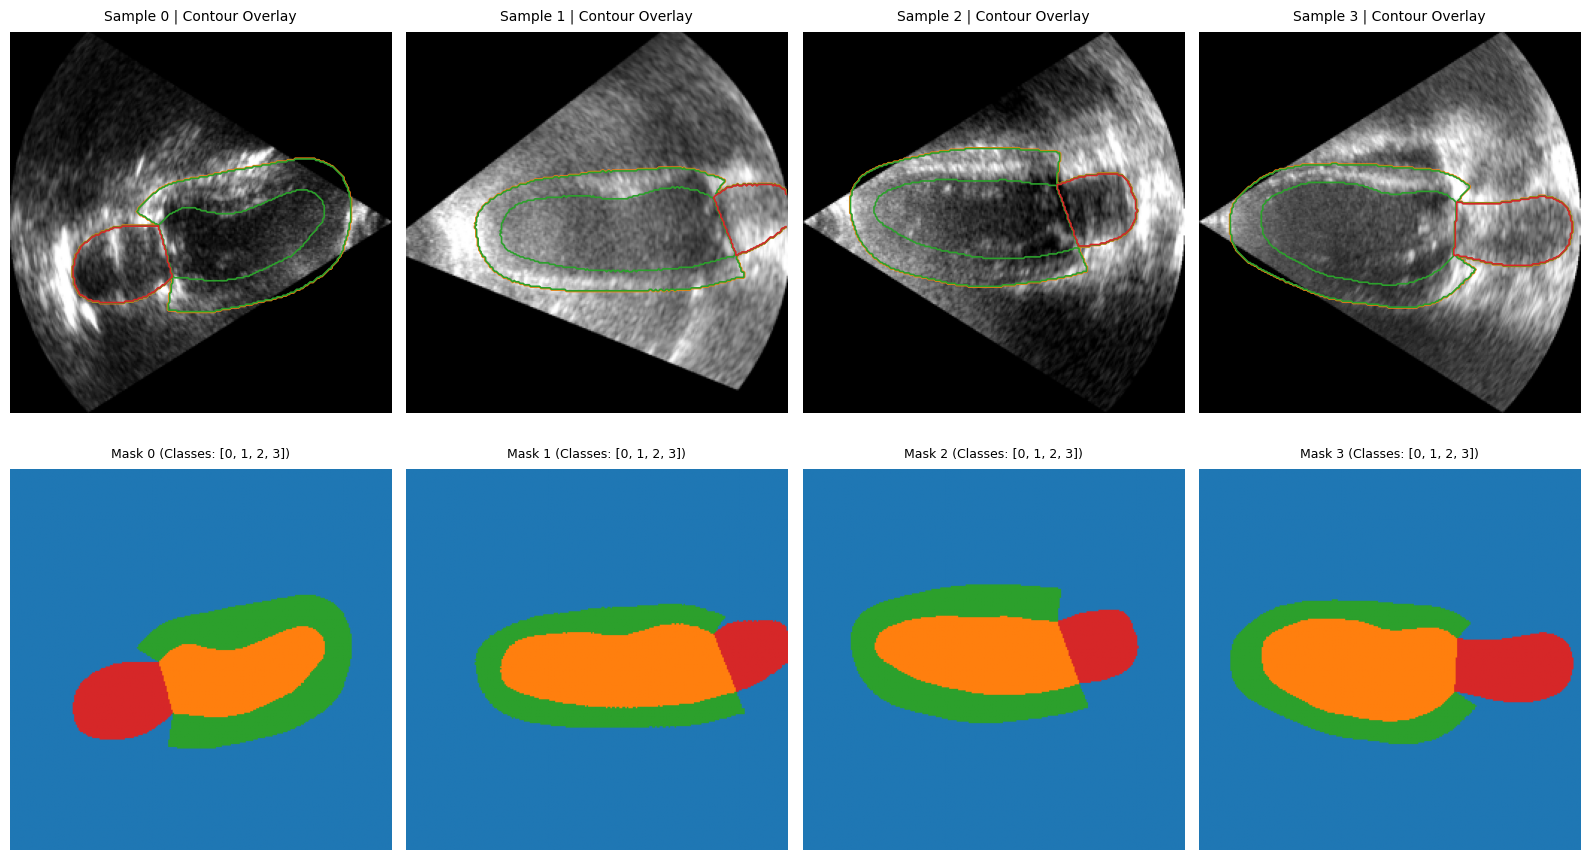

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Explicit CAMUS class palette: [0: Background (Unused), 1: LV Cavity, 2: Myocardium, 3: LA]
camus_cmap = ListedColormap(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
contour_colors = ["#ff7f0e", "#2ca02c", "#d62728"]  # Boundaries for 0|1, 1|2, 2|3

MEAN = np.array([0.485, 0.456, 0.406])
STD = np.array([0.229, 0.224, 0.225])

images, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(16, 9))

for col in range(4):
    # Denormalize input image tensor
    gray = (
        (images[col].permute(1, 2, 0).numpy() * STD + MEAN)
        .clip(0, 1)
        .mean(axis=-1)
    )
    mask_np = masks[col].numpy()

    # Clean list of standard Python integers (prevents np.int64 verbose string)
    unique_classes = [int(c) for c in np.unique(mask_np)]

    # Row 0: Direct Contour Overlay on Image Array (Decisive Alignment Proof)
    axes[0, col].imshow(gray, cmap="gray")
    axes[0, col].contour(
        mask_np, levels=[0.5, 1.5, 2.5], linewidths=1.2, colors=contour_colors
    )
    axes[0, col].set_title(
        f"Sample {col} | Contour Overlay", fontsize=10, pad=8
    )
    axes[0, col].axis("off")

    # Row 1: Target Mask Matrix with Explicit Categorical Palette
    axes[1, col].imshow(mask_np, cmap=camus_cmap, vmin=0, vmax=3)
    axes[1, col].set_title(
        f"Mask {col} (Classes: {unique_classes})", fontsize=9, pad=8
    )
    axes[1, col].axis("off")

plt.tight_layout(h_pad=2.0)
plt.show()

In [6]:
   print((NIFTI / "patient0001" / "Info_2CH.cfg").read_text())

ED: 1
ES: 18
NbFrame: 18
Sex: F
Age: 56
ImageQuality: Good
EF: 54
FrameRate: 48.4



## Clinical Endpoint: Simpson LVEF from Expert Masks vs. Reference

### a. parse per-view metadata; determine reference EF semantics.

In [7]:
REQUIRED_CFG_KEYS = ("ED", "ES", "NbFrame", "Sex", "Age", "ImageQuality", "EF", "FrameRate")


def parse_cfg(path: Path) -> dict:
    """Parse a CAMUS per-view metadata file; raise if required keys are absent.

    Blank lines and surrounding whitespace are tolerated. Missing keys are a
    hard error naming the file: silent sentinels (-1, NaN) would corrupt
    cohort statistics with no traceback to explain why.
    """
    if not path.exists():
        raise FileNotFoundError(f"Metadata file missing: {path}")
    out = {}
    for line in path.read_text().splitlines():
        line = line.strip()
        if line and ":" in line:
            k, v = line.split(":", 1)
            out[k.strip()] = v.strip()
    missing = set(REQUIRED_CFG_KEYS) - out.keys()
    if missing:
        raise ValueError(f"{path}: missing keys {sorted(missing)}")
    return out


rows = []
for pid in sorted(p.name for p in NIFTI.iterdir() if p.is_dir()):
    for view in ("2CH", "4CH"):
        cfg = parse_cfg(NIFTI / pid / f"Info_{view}.cfg")
        rows.append({"patient": pid, "view": view,
                     "ed_frame": int(cfg["ED"]), "es_frame": int(cfg["ES"]),
                     "quality": cfg["ImageQuality"], "ref_ef": float(cfg["EF"]),
                     "sex": cfg["Sex"], "age": int(cfg["Age"])})
meta = pd.DataFrame(rows)

pivot = meta.pivot(index="patient", columns="view", values="ref_ef")
n_disagree = int((pivot["2CH"] != pivot["4CH"]).sum())
print(f"patients audited: {len(pivot)}")
print(f"patients with differing 2CH/4CH reference EF: {n_disagree} / {len(pivot)}")
print("quality distribution per view:")
print(meta.groupby(["view", "quality"]).size().unstack(fill_value=0))

patients audited: 500
patients with differing 2CH/4CH reference EF: 0 / 500
quality distribution per view:
quality  Good  Medium  Poor
view                       
2CH       217     214    69
4CH       288     165    47


### b. method-of-disks volumes from segmentation masks (ASE 2015).

In [8]:
from scipy import ndimage


def largest_component(binary: np.ndarray) -> np.ndarray:
    """Keep only the largest connected blob; removes stray prediction specks."""
    labs, n = ndimage.label(binary)
    if n <= 1:
        return binary
    sizes = ndimage.sum(binary, labs, index=np.arange(1, n + 1))
    return labs == int(np.argmax(sizes)) + 1


def cavity_profile(mask: np.ndarray, n_disks: int = 20):
    """Apex-to-base disk widths (px) and long-axis length (px) of the LV cavity.

    The basal end is anchored by the left-atrium (label 3) centroid, so disk i
    denotes the same fractional depth from the apex in every view - the pairing
    assumption behind biplane Simpson. Falls back to the width profile
    (narrow end = apex) when no atrium is present.
    """
    cavity = largest_component(mask == 1)
    ys, xs = np.nonzero(cavity)
    if len(xs) < 50:
        return np.zeros(n_disks), 0.0
    raw = np.stack([xs, ys], axis=1).astype(float)
    center = raw.mean(0)
    pts = raw - center
    evals, evecs = np.linalg.eigh(np.cov(pts.T))
    long_axis, short_axis = evecs[:, -1], evecs[:, 0]
    proj, orth = pts @ long_axis, pts @ short_axis

    la_ys, la_xs = np.nonzero(mask == 3)
    if len(la_xs) > 20:                                  # anatomical anchor: atrium = base
        la_proj = (np.stack([la_xs, la_ys], axis=1).astype(float) - center) @ long_axis
        if la_proj.mean() < proj.mean():
            proj = -proj
    else:                                                # fallback: narrow end is apex
        lo = proj < np.percentile(proj, 20)
        hi = proj > np.percentile(proj, 80)
        if (orth[lo].max() - orth[lo].min()) > (orth[hi].max() - orth[hi].min()):
            proj = -proj

    edges = np.linspace(proj.min(), proj.max(), n_disks + 1)
    widths = []
    for a, b in zip(edges[:-1], edges[1:]):
        sel = (proj >= a) & (proj < b)
        widths.append(float(orth[sel].max() - orth[sel].min()) if sel.any() else 0.0)
    return np.array(widths), float(proj.max() - proj.min())


def volume_ml(widths_px: np.ndarray, length_px: float, spacing_mm, partner_px=None) -> float:
    """Disk summation in mL; spacing read per header, never assumed."""
    mm = float(np.mean(spacing_mm))
    h_cm = length_px * mm / 10.0 / len(widths_px)
    d1 = widths_px * mm / 10.0
    if partner_px is None:
        return float((np.pi / 4) * np.sum(d1 ** 2) * h_cm)
    d2 = partner_px * mm / 10.0
    return float((np.pi / 4) * np.sum(d1 * d2) * h_cm)


def load_mask(pid: str, view: str, instant: str):
    """Mask array plus its own header spacing, via the tolerant path helper."""
    path = frame_path(NIFTI / pid, view, instant, mask=True)
    img = nib.load(path)
    return np.squeeze(np.asarray(img.dataobj)), img.header.get_zooms()[:2]


def patient_volumes(pid: str):
    """(single-plane volumes per view, biplane volumes) for one patient."""
    single, prof = {}, {}
    for view in ("2CH", "4CH"):
        for instant in ("ED", "ES"):
            mask, spacing = load_mask(pid, view, instant)
            w, l = cavity_profile(mask)
            prof[(view, instant)] = (w, l, spacing)
            single[(view, instant)] = volume_ml(w, l, spacing)
    biplane = {}
    for instant in ("ED", "ES"):
        (w1, l1, s1), (w2, l2, _) = prof[("2CH", instant)], prof[("4CH", instant)]
        biplane[instant] = volume_ml(w1, (l1 + l2) / 2, s1, partner_px=w2)
    return single, biplane


def ef(edv: float, esv: float) -> float:
    return (edv - esv) / edv * 100.0 if edv > 0 else np.nan

### c. implementation check: computed vs. expert reference EF (val split).

In [9]:
ref_ef = {(r.patient, r.view): r.ref_ef for r in meta.itertuples()}   

records = []
for pid in val_ids:                                   
    single, biplane = patient_volumes(pid)
    for view in ("2CH", "4CH"):
        records.append({"patient": pid, "mode": f"single-{view}",
                        "computed_ef": ef(single[(view, "ED")], single[(view, "ES")]),
                        "ref_ef": ref_ef[(pid, view)]})
    records.append({"patient": pid, "mode": "biplane",
                    "computed_ef": ef(biplane["ED"], biplane["ES"]),
                    "ref_ef": ref_ef[(pid, "2CH")]})  

check = pd.DataFrame(records)

rows = []
for mode, g in check.groupby("mode"):                
    diff = g.computed_ef - g.ref_ef
    rows.append({"mode": mode,
                 "mean_abs_err": diff.abs().mean(),
                 "bias": diff.mean(),
                 "pearson_r": g.computed_ef.corr(g.ref_ef)})
summary = pd.DataFrame(rows).set_index("mode")

print(f"--- validation summary (val split, n={len(val_ids)} patients) ---")
print(summary.round(2))
print("\n--- sample rows ---")
print(check.head(8).round(1))

--- validation summary (val split, n=50 patients) ---
            mean_abs_err   bias  pearson_r
mode                                      
biplane             7.67   7.67       0.97
single-2CH         10.59  10.59       0.92
single-4CH          6.93   3.74       0.84

--- sample rows ---
       patient        mode  computed_ef  ref_ef
0  patient0200  single-2CH         61.3    45.0
1  patient0200  single-4CH         49.2    45.0
2  patient0200     biplane         55.8    45.0
3  patient0206  single-2CH         61.9    52.0
4  patient0206  single-4CH         57.8    52.0
5  patient0206     biplane         60.1    52.0
6  patient0230  single-2CH         39.7    32.0
7  patient0230  single-4CH         33.2    32.0


## U-Net Architecture and Training Loop

In [10]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.4 MB/s eta 0:00:0000:0100:01


In [11]:
import numpy as np
import segmentation_models_pytorch as smp
import torch
from torch.nn import CrossEntropyLoss
from torch.optim import AdamW

# Device and Model Definition
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4,
).to(device)

# Loss Function (Combined Soft-Dice + Cross Entropy)
dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True)
ce_loss = CrossEntropyLoss()

def criterion(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    # Defensive squeeze ensures (B, H, W) shape for CE and Dice losses
    if targets.ndim == 4:
        targets = targets.squeeze(1)
    targets = targets.long()
    return dice_loss(logits, targets) + ce_loss(logits, targets)

# Optimizer and Scheduler
optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
EPOCHS = 20
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# Training Loop
history = {"train_loss": [], "val_loss": [], "val_dice_fg": []}

for epoch in range(EPOCHS):
    # Training Phase
    model.train()
    train_losses = []
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)
        
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    
    # Validation Phase
    model.eval()
    val_losses, val_dices = [], []
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            
            logits = model(images)
            loss = criterion(logits, masks)
            val_losses.append(loss.item())
            
            # Compute Foreground-Only Macro-Averaged Dice (Classes 1, 2, 3)
            if masks.ndim == 4:
                masks = masks.squeeze(1)
            preds = logits.argmax(dim=1)
            
            tp, fp, fn, tn = smp.metrics.get_stats(preds, masks, mode="multiclass", num_classes=4)
            dice_per_class = smp.metrics.fbeta_score(tp, fp, fn, tn, beta=1.0, reduction="none")
            
            # Exclude background (index 0) to prevent metric inflation
            foreground_dice = dice_per_class[:, 1:].mean().item()
            val_dices.append(foreground_dice)
            
    scheduler.step()
    
    # Epoch Summary
    t_loss = float(np.mean(train_losses))
    v_loss = float(np.mean(val_losses))
    v_dice = float(np.mean(val_dices))
    
    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["val_dice_fg"].append(v_dice)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Dice (FG): {v_dice:.4f}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Epoch 01/20 | Train Loss: 1.3935 | Val Loss: 0.8729 | Val Dice (FG): 0.8385
Epoch 02/20 | Train Loss: 0.6392 | Val Loss: 0.4655 | Val Dice (FG): 0.8701
Epoch 03/20 | Train Loss: 0.3584 | Val Loss: 0.3113 | Val Dice (FG): 0.8773
Epoch 04/20 | Train Loss: 0.2664 | Val Loss: 0.2361 | Val Dice (FG): 0.8989
Epoch 05/20 | Train Loss: 0.2263 | Val Loss: 0.2240 | Val Dice (FG): 0.8976
Epoch 06/20 | Train Loss: 0.2038 | Val Loss: 0.2174 | Val Dice (FG): 0.8954
Epoch 07/20 | Train Loss: 0.1924 | Val Loss: 0.2094 | Val Dice (FG): 0.8998
Epoch 08/20 | Train Loss: 0.1820 | Val Loss: 0.1915 | Val Dice (FG): 0.9038
Epoch 09/20 | Train Loss: 0.1718 | Val Loss: 0.1848 | Val Dice (FG): 0.9089
Epoch 10/20 | Train Loss: 0.1661 | Val Loss: 0.1911 | Val Dice (FG): 0.9064
Epoch 11/20 | Train Loss: 0.1608 | Val Loss: 0.2062 | Val Dice (FG): 0.8992
Epoch 12/20 | Train Loss: 0.1547 | Val Loss: 0.1829 | Val Dice (FG): 0.9101
Epoch 13/20 | Train Loss: 0.1455 | Val Loss: 0.1820 | Val Dice (FG): 0.9107
Epoch 14/20 

### Checkpoint: persist the selected (best-val-dice) weights and history.

In [12]:
import json
import os
import torch

# Persist model weights and training history
torch.save(model.state_dict(), "/kaggle/working/unet_resnet34_camus.pt")

with open("/kaggle/working/history.json", "w") as fh:
    json.dump(history, fh, indent=2)

print("Saved files in /kaggle/working:", os.listdir("/kaggle/working"))

Saved files in /kaggle/working: ['history.json', '.virtual_documents', 'unet_resnet34_camus.pt']


## Isolated Test Evaluation

### a. Isolated test evaluation: per-class Dice and HD95 at native resolution

In [13]:
from scipy import ndimage


def get_native_mask_and_spacing(pid: str, view: str, instant: str):
    """Ground-truth mask plus its true physical spacing, read from the NIfTI header."""
    nii = nib.load(frame_path(NIFTI / pid, view, instant, mask=True))
    mask = np.squeeze(np.asarray(nii.dataobj)).astype(np.uint8)
    zooms = nii.header.get_zooms()[:2]          # aligned to array axes (h, w)
    return mask, (float(zooms[0]), float(zooms[1]))


def predict_patient(pid: str) -> dict:
    """Argmax predictions for a patient's four frames, resampled to native grids."""
    ds = CamusDataset([pid], NIFTI, build_transform("val"))
    keys = [(v, i) for v in ("2CH", "4CH") for i in ("ED", "ES")]
    preds = {}
    model.eval()
    with torch.no_grad():
        for key, (image, _) in zip(keys, ds):
            logits = model(image.unsqueeze(0).to(device))
            pred = logits.argmax(1).squeeze(0).cpu().numpy().astype(np.uint8)
            native = np.squeeze(np.asarray(
                nib.load(frame_path(NIFTI / pid, key[0], key[1], mask=True)).dataobj)).shape
            preds[key] = cv2.resize(pred, (native[1], native[0]),
                                    interpolation=cv2.INTER_NEAREST)
    return preds


def dice_coef(a: np.ndarray, b: np.ndarray, c: int) -> float:
    pa, pb = (a == c), (b == c)
    return 2.0 * (pa & pb).sum() / max(pa.sum() + pb.sum(), 1)


def hd95_mm(a: np.ndarray, b: np.ndarray, c: int, spacing: tuple) -> float:
    """95th-percentile Hausdorff distance in mm, using true per-axis spacing."""
    pa, pb = (a == c), (b == c)
    if not pa.any() or not pb.any():
        return np.nan
    da = ndimage.distance_transform_edt(~pa, sampling=spacing)
    db = ndimage.distance_transform_edt(~pb, sampling=spacing)
    sa = pa & ~ndimage.binary_erosion(pa)
    sb = pb & ~ndimage.binary_erosion(pb)
    if not sa.any() or not sb.any():
        return np.nan
    return float(max(np.percentile(db[sa], 95), np.percentile(da[sb], 95)))


rows = []
for pid in test_ids:                             # single pass; results are final
    for (view, instant), pm in predict_patient(pid).items():
        gm, spacing = get_native_mask_and_spacing(pid, view, instant)
        for c in (1, 2, 3):
            rows.append({"patient": pid, "view": view, "instant": instant, "class": c,
                         "dice": dice_coef(pm, gm, c),
                         "hd95_mm": hd95_mm(pm, gm, c, spacing)})
test_metrics = pd.DataFrame(rows)

print(test_metrics.groupby("class")[["dice", "hd95_mm"]].agg(["mean", "std"]).round(3))

/tmp/ipykernel_116/960861732.py:31: UserWarning: Argument(s) 'cval, cval_mask' are not valid for transform Affine
  A.Affine(


        dice        hd95_mm       
        mean    std    mean    std
class                             
1      0.934  0.034   3.834  1.805
2      0.874  0.039   3.959  1.684
3      0.916  0.053   4.135  3.064


### b. Clinical endpoint on predictions, mask-to-mask under the fixed estimator.

In [20]:
recs = []
for pid in test_ids:
    preds = predict_patient(pid)
    prof_p = {}
    for (view, instant), pm in preds.items():
        w, l = cavity_profile(pm)
        sp = load_mask(pid, view, instant)[1]
        prof_p[(view, instant)] = (w, l, sp)
    biplane_p = {}
    for inst in ("ED", "ES"):
        (w1, l1, s1), (w2, l2, _) = prof_p[("2CH", inst)], prof_p[("4CH", inst)]
        biplane_p[inst] = volume_ml(w1, (l1 + l2) / 2, s1, partner_px=w2)
    # expert-mask side, same fixed estimator
    _, biplane_e = patient_volumes(pid)
    recs.append({"patient": pid,
                 "ef_pred": ef(biplane_p["ED"], biplane_p["ES"]),
                 "ef_expert_masks": ef(biplane_e["ED"], biplane_e["ES"]),
                 "ref_ef": ref_ef[(pid, "2CH")]})
ef_test = pd.DataFrame(recs)

d_mask = ef_test.ef_pred - ef_test.ef_expert_masks
d_ref = ef_test.ef_pred - ef_test.ref_ef
print(f"pred vs expert-mask EF | MAE {d_mask.abs().mean():.2f} | "
      f"bias {d_mask.mean():+.2f} | r {ef_test.ef_pred.corr(ef_test.ef_expert_masks):.3f}")
print(f"pred vs clinical ref | MAE {d_ref.abs().mean():.2f} | "
      f"bias {d_ref.mean():+.2f} | r {ef_test.ef_pred.corr(ef_test.ref_ef):.3f}")
print(ef_test.head(8).round(1))

/tmp/ipykernel_116/960861732.py:31: UserWarning: Argument(s) 'cval, cval_mask' are not valid for transform Affine
  A.Affine(


pred vs expert-mask EF | MAE 4.76 | bias -1.78 | r 0.875
pred vs clinical ref | MAE 7.64 | bias +5.78 | r 0.856
       patient  ef_pred  ef_expert_masks  ref_ef
0  patient0027     41.9             48.7    40.0
1  patient0047     38.1             38.9    38.0
2  patient0051     37.0             36.2    29.0
3  patient0052     10.7              9.2     5.0
4  patient0187     47.9             48.6    38.0
5  patient0189     81.6             74.5    69.0
6  patient0191     26.3             28.2    26.0
7  patient0194     70.2             66.1    64.0
